# GPU Campaign — Paper Figures

Generates the four figures of the GPU experimental section from the raw
measurement tables (`measure_results.ods` = RTX 3060, `1070_measure_results.ods`
= GTX 1070). Run all cells top to bottom; figures are saved to `figures/`
as PDF (for LaTeX) and PNG (for preview).

Requirements: `pandas`, `numpy`, `matplotlib`, `odfpy` (`pip install odfpy`).

| Figure | Claim it carries |
|---|---|
| 1 | Configuration story: ramp, saturation, crown flip, roof, PLR placement (P5 backdrop) |
| 2 | P1 twinning + P2 barrier gap, both devices |
| 3 | P3: DTCR's win/loss map at the saturated plateau |
| 4 | DTCR in the latency regime (smallest batch) |


In [8]:
# Requires: pandas, numpy, matplotlib, odfpy  (pip install odfpy)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

# ---- global style: clean, serif, publication-oriented ----
mpl.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif"],
    "mathtext.fontset":  "dejavuserif",
    "font.size":         9.5,
    "axes.titlesize":    10.5,
    "axes.labelsize":    10,
    "legend.fontsize":   9,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.color":        "0.88",
    "grid.linewidth":    0.6,
    "axes.axisbelow":    True,
    "lines.linewidth":   1.8,
    "lines.markersize":  4.2,
    "figure.dpi":        110,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

DEVICES = {
    "3060": dict(file="../results/3060_measure_results.ods",      name="RTX 3060 (Ampere)", roof=45.0),
    "1070": dict(file="../results/1070_measure_results.ods", name="GTX 1070 (Pascal)", roof=32.0),
}
ORDERS  = [2, 4, 8, 16]                      # filter order = 2 * N_SECTIONS
CONFIGS = ["32x32", "32x64", "32x128", "64x64"]

# Okabe–Ito colorblind-safe palette, one color per configuration
CFG_COLOR  = {"32x32": "#0072B2", "32x64": "#E69F00",
              "32x128": "#009E73", "64x64": "#D55E00"}
CFG_MARKER = {"32x32": "o", "32x64": "s", "32x128": "^", "64x64": "D"}
CFG_LABEL  = {"32x32": r"$32{\times}32$",  "32x64": r"$32{\times}64$",
              "32x128": r"$32{\times}128$", "64x64": r"$64{\times}64$"}
PLR_STYLE  = dict(color="#444444", marker="x", linestyle="--",
                  markersize=5, markeredgewidth=1.4)

In [9]:
def read_campaign(path):
    """Parse one .ods campaign sheet.

    Layout: repeated blocks of
        <alg> <order>th | 'batch size'
        'tb size'       | 16 17 ... 25         (log2 batch exponents)
        <config rows>   | throughput in GS/s
    Returns {(alg, order): DataFrame[config x exponent]}. The PLR blocks
    have a single row (one geometry per order); it is relabeled 'PLR'.
    """
    raw = pd.read_excel(path, engine="odf", header=None)
    out, i = {}, 0
    while i < len(raw):
        if str(raw.iloc[i, 1]).strip() == "batch size":
            alg, ordw = str(raw.iloc[i, 0]).strip().split()
            order = int(ordw.rstrip("stndrh").rstrip("t"))  # '2nd'->2 ... '16th'->16
            exps = [int(x) for x in raw.iloc[i + 1, 1:]]
            rows, j = {}, i + 2
            while (j < len(raw) and pd.notna(raw.iloc[j, 0])
                   and str(raw.iloc[j, 1]).strip() != "batch size"):
                label = str(raw.iloc[j, 0]).strip().replace(" ", "")
                if alg.lower() == "plr":
                    label = "PLR"
                rows[label] = raw.iloc[j, 1:].astype(float).to_numpy()
                j += 1
            out[(alg.lower(), order)] = pd.DataFrame(rows, index=exps).T
            i = j
        else:
            i += 1
    return out

DATA = {dev: read_campaign(meta["file"]) for dev, meta in DEVICES.items()}
EXPS = list(DATA["3060"][("ph", 2)].columns)          # [16, ..., 25]

def plateau(series):
    """Plateau statistic: mean of the two largest batches (2^24, 2^25)."""
    return np.nanmean(series[[24, 25]])

print("parsed blocks per device:",
      {d: len(DATA[d]) for d in DATA}, "| batch exponents:", EXPS)

def batch_axis(ax):
    ax.set_xticks([16, 18, 20, 22, 24])
    ax.set_xticklabels([r"$2^{16}$", r"$2^{18}$", r"$2^{20}$",
                        r"$2^{22}$", r"$2^{24}$"])
    ax.set_xlim(15.6, 25.4)

parsed blocks per device: {'3060': 16, '1070': 16} | batch exponents: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


## Figure 1 — PH across the configurations, with PLR and the memory roof
Two device rows × four order columns. Carries the configuration story: small-batch
ranking by group count, saturation onset, the crown flip between rows, the fall from
the roof with order, and PLR's placement (absent at order 16 by disqualification).

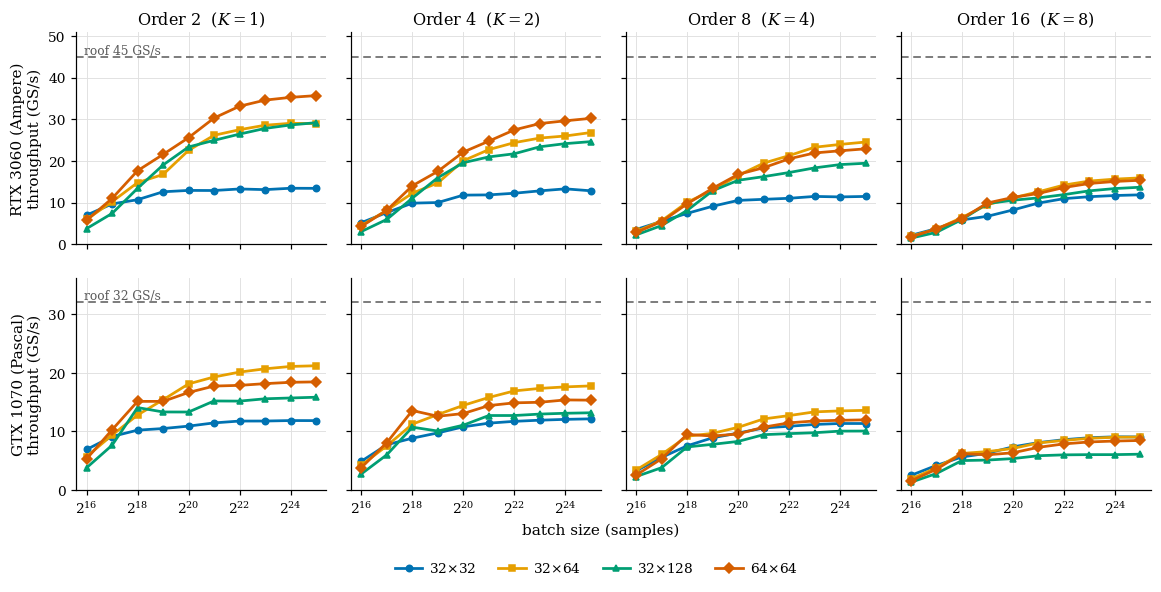

In [10]:
# PH across the four configurations, against the memory roof.
# 2 device rows x 4 order columns. Carries the configuration story:
# ramp ranking by group count, saturation onset, the crown flip
# between rows, 32x128's device-dependent standing, the fall from
# the roof with order.
def figure1():
    fig, axes = plt.subplots(2, 4, figsize=(12.6, 5.4), sharex=True,
                             gridspec_kw=dict(hspace=0.16, wspace=0.10))
    for r, dev in enumerate(["3060", "1070"]):
        roof = DEVICES[dev]["roof"]
        for c, order in enumerate(ORDERS):
            ax = axes[r, c]
            ph = DATA[dev][("ph", order)]
            for cfg in CONFIGS:
                ax.plot(EXPS, ph.loc[cfg], color=CFG_COLOR[cfg],
                        marker=CFG_MARKER[cfg], label=CFG_LABEL[cfg])
            ax.axhline(roof, color="0.35", lw=1.0, ls=(0, (5, 3)))
            ax.set_ylim(0, roof * 1.13)
            batch_axis(ax)
            if r == 0:
                ax.set_title(f"Order {order}  ($K={order//2}$)", pad=5)
            if c == 0:
                ax.set_ylabel(f'{DEVICES[dev]["name"]}\nthroughput (GS/s)')
                ax.text(15.9, roof, f"roof {roof:g} GS/s", fontsize=8,
                        color="0.35", va="bottom", ha="left")
            else:
                ax.tick_params(labelleft=False)
            if r == 1 and c == 1:
                ax.set_xlabel("batch size (samples)", x=1.0)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=4, loc="lower center",
               bbox_to_anchor=(0.5, -0.055), frameon=False,
               columnspacing=1.6, handletextpad=0.5)
    # fig.suptitle("PH throughput across configurations, against the memory roof",
    #              y=0.99, fontsize=11)
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig1_ph_configs.{ext}")
    return fig

fig1 = figure1()

## Figure 2 — operations are free, barriers are not (saturated region)
Twelve single-warp (STCR − PH)/PH cells hug zero inside the ±5% session-noise band
(P1); the four 64×64 curves escape it, ordered by $K$ and ≈3× deeper on Pascal (P2).
On Pascal the single-warp fan widens at high order — arithmetic intensity approaching
the balance point, the model's own boundary.

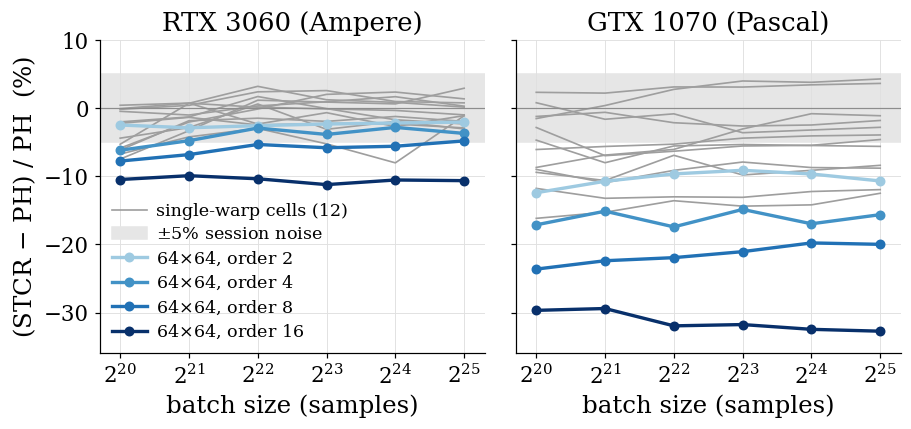

In [11]:
# Operations are free, barriers are not: (STCR - PH)/PH in percent.
# Twelve single-warp cells hug zero inside the session-noise band (P1);
# the four 64x64 curves escape it, ordered by K, ~3x deeper on Pascal (P2).
K_COLOR = {2: "#9ecae1", 4: "#4292c6", 8: "#2171b5", 16: "#08306b"}

def figure2():
    SAT = [e for e in EXPS if e >= 20]             # saturated region only:
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.7), sharey=True,
                             gridspec_kw=dict(wspace=0.08))
    for ax, dev in zip(axes, ["3060", "1070"]):
        ax.axhspan(-5, 5, color="0.9", zorder=0)
        ax.axhline(0, color="0.55", lw=0.8)
        for order in ORDERS:                       # single-warp cells
            ph, st = DATA[dev][("ph", order)], DATA[dev][("stcr", order)]
            for cfg in ["32x32", "32x64", "32x128"]:
                r = 100 * (st.loc[cfg] - ph.loc[cfg]) / ph.loc[cfg]
                ax.plot(SAT, r[SAT], color="0.62", lw=1.1, zorder=1)
        for order in ORDERS:                       # the 64x64 gap
            ph, st = DATA[dev][("ph", order)], DATA[dev][("stcr", order)]
            r = 100 * (st.loc["64x64"] - ph.loc["64x64"]) / ph.loc["64x64"]
            ax.plot(SAT, r[SAT], color=K_COLOR[order], marker="o", zorder=3,
                    lw=2.2, markersize=5.5,
                    label=f"$64{{\\times}}64$, order {order}")
        ax.set_xticks([20, 21, 22, 23, 24, 25])
        ax.set_xticklabels([r"$2^{20}$", r"$2^{21}$", r"$2^{22}$",
                            r"$2^{23}$", r"$2^{24}$", r"$2^{25}$"])
        ax.set_xlim(19.7, 25.3)
        ax.tick_params(labelsize=14)
        ax.set_title(DEVICES[dev]["name"], pad=6, fontsize=17)
        ax.set_xlabel("batch size (samples)", fontsize=16)
    axes[0].set_ylabel(r"(STCR $-$ PH) / PH  (%)", fontsize=16)
    axes[0].set_ylim(-36, 10)
    gray = mpl.lines.Line2D([], [], color="0.62", lw=1.1)
    band = mpl.patches.Patch(color="0.9")
    h, l = axes[1].get_legend_handles_labels()
    axes[0].legend([gray, band] + h,
                   ["single-warp cells (12)", r"$\pm 5\%$ session noise"] + l,
                   loc="lower left", frameon=False, fontsize=11.5,
                   handletextpad=0.5, borderaxespad=0.3, labelspacing=0.35)
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig2_twinning_barrier.{ext}")
    return fig

fig2 = figure2()

## Figures 3 & 4 — DTCR's conditional map (P3)
(DTCR − PH)/PH per (order, configuration) cell; blue = DTCR wins, red = loses.
Figure 3: the saturated plateau — wins exactly where hiding binds (32×128 column),
never wins 32×64, sign structure flips with the device. Figure 4: the smallest batch
— the latency regime, which DTCR owns almost unconditionally.

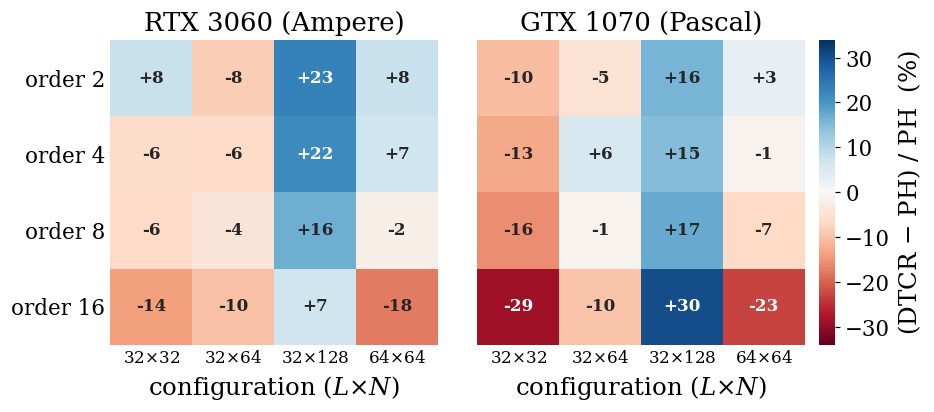

In [12]:
# DTCR's conditional map: (DTCR - PH)/PH per (order, config) cell.
# Figure 3 at the saturated plateau (throughput regime), Figure 4 at
# 2^16 (latency regime). Blue = DTCR wins, red = DTCR loses.
def dtcr_map(at, fname, vlim):
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6),
                             gridspec_kw=dict(wspace=0.12))
    cmap = plt.get_cmap("RdBu")
    for ax, dev in zip(axes, ["3060", "1070"]):
        grid = np.zeros((len(ORDERS), len(CONFIGS)))
        for i, order in enumerate(ORDERS):
            ph, dt = DATA[dev][("ph", order)], DATA[dev][("dtcr", order)]
            for j, cfg in enumerate(CONFIGS):
                a, b = (plateau(dt.loc[cfg]), plateau(ph.loc[cfg])) if at == "plateau" \
                       else (dt.loc[cfg][16], ph.loc[cfg][16])
                grid[i, j] = 100 * (a - b) / b
        im = ax.imshow(grid, cmap=cmap, vmin=-vlim, vmax=vlim, aspect="auto")
        for i in range(len(ORDERS)):
            for j in range(len(CONFIGS)):
                dark = abs(grid[i, j]) > 0.55 * vlim
                ax.text(j, i, f"{grid[i, j]:+.0f}", ha="center", va="center",
                        fontsize=11, fontweight="bold",
                        color="white" if dark else "0.15")
        ax.set_xticks(range(len(CONFIGS)))
        ax.set_xticklabels([CFG_LABEL[c] for c in CONFIGS], fontsize=11)
        ax.set_xlabel(r"configuration ($L{\times}N$)", fontsize=16)
        ax.set_yticks(range(len(ORDERS)))
        if dev == "3060":
            ax.set_yticklabels([f"order {o}" for o in ORDERS], fontsize=14)
        else:
            ax.tick_params(labelleft=False)
        ax.set_title(DEVICES[dev]["name"], pad=6, fontsize=17)
        ax.grid(False)
        for s in ax.spines.values():
            s.set_visible(False)
        ax.tick_params(length=0)
    cb = fig.colorbar(im, ax=axes, fraction=0.033, pad=0.02)
    cb.set_label(r"(DTCR $-$ PH) / PH  (%)", fontsize=16)
    cb.ax.tick_params(labelsize=14)
    cb.outline.set_visible(False)
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{fname}.{ext}")
    return fig

def figure3():
    return dtcr_map("plateau", "fig3_dtcr_map_plateau", 34)

def figure4():
    return dtcr_map("small", "fig4_dtcr_map_smallbatch", 68)

fig3 = figure3()

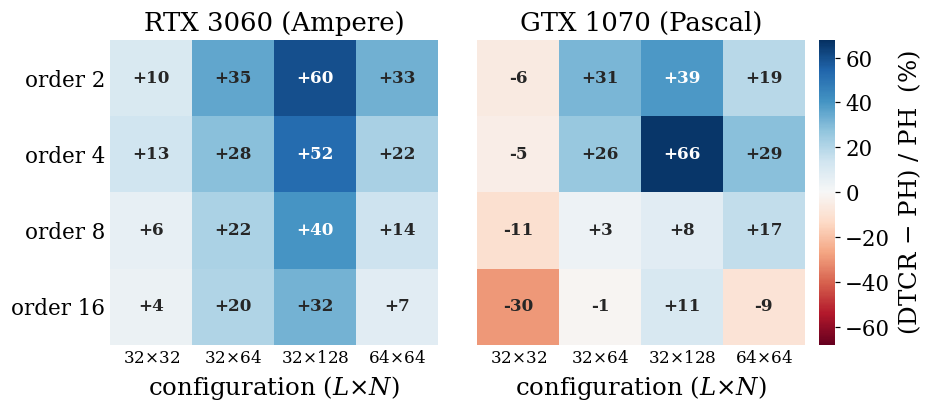

In [13]:
fig4 = figure4()

## Figure 5 — the four-algorithm verdict
Each algorithm at its best configuration per order, as a fraction of the device
roof; the crowning $L{\times}N$ configuration is labeled in context at each order
column, with per-algorithm exceptions labeled beside their points. The cascade
crowns beat PLR at every admissible order on both devices; PLR's slope is the
steepest ($k\log_2 B$ work law vs the cascades' fixed per-section bill) and its
line ends at order 8 by disqualification; the descent from ~80% to ~30% of roof
is the transition from memory-bound to section-cost-bound.

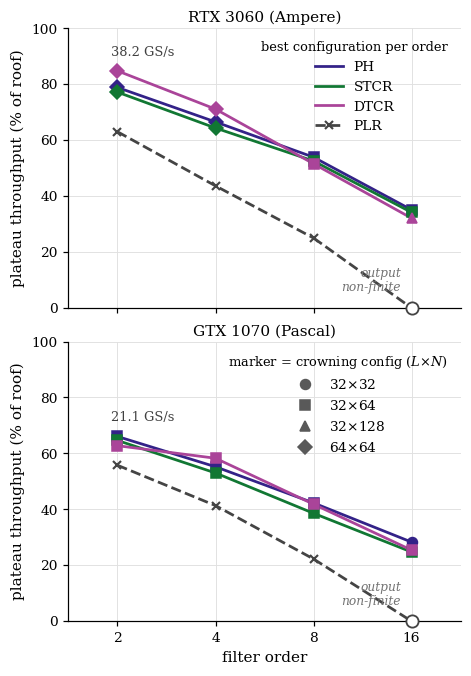

In [14]:
from matplotlib.lines import Line2D

ALG_COLOR = {"ph": "#332288", "stcr": "#117733", "dtcr": "#AA4499"}
ALG_LABEL = {"ph": "PH", "stcr": "STCR", "dtcr": "DTCR"}

def figure5():
    fig, axes = plt.subplots(2, 1, figsize=(4.6, 7.0), sharex=True,
                             gridspec_kw=dict(hspace=0.12))
    xpos = np.log2(ORDERS)
    # connector segment style: PLR line style without its 'x' markers
    plr_seg = {k: v for k, v in PLR_STYLE.items() if not k.startswith("marker")}
    for ax, dev in zip(axes, ["3060", "1070"]):
        roof = DEVICES[dev]["roof"]
        best_gs, best_xy = 0.0, None
        for alg in ["ph", "stcr", "dtcr"]:
            ys, cfgs = [], []
            for order in ORDERS:
                blk = DATA[dev][(alg, order)]
                cfg = max(CONFIGS, key=lambda c: plateau(blk.loc[c]))
                y = 100 * plateau(blk.loc[cfg]) / roof
                ys.append(y)
                cfgs.append(cfg)
            ax.plot(xpos, ys, color=ALG_COLOR[alg], lw=1.8, zorder=2,
                    label=ALG_LABEL[alg])
            for x, y, c in zip(xpos, ys, cfgs):    # marker = crowning config
                ax.plot([x], [y], marker=CFG_MARKER[c], markersize=6.5,
                        color=ALG_COLOR[alg], linestyle="none", zorder=3)
            if ys[0] * roof / 100 > best_gs:       # order-2 record
                best_gs, best_xy = ys[0] * roof / 100, (xpos[0], ys[0])
        ax.annotate(f"{best_gs:.1f} GS/s", xy=best_xy,
                    xytext=(-4, 8), textcoords="offset points",
                    fontsize=8.5, color="0.25", ha="left", va="bottom")
        # ---- PLR: invalid = non-finite OR zero (data stores 0 at order 16) ----
        plr = np.array([100 * plateau(DATA[dev][("plr", o)].loc["PLR"]) / roof
                        for o in ORDERS])
        valid = np.isfinite(plr) & (plr > 0)
        ax.plot(xpos[valid], plr[valid], label="PLR", zorder=2, **PLR_STYLE)
        if (~valid).any():
            x_bad = xpos[~valid][0]
            ax.plot([xpos[valid][-1], x_bad], [plr[valid][-1], 0],
                    zorder=2, **plr_seg)           # dashed drop, no marker
            ax.plot([x_bad], [0], marker="o", markersize=8,
                    markerfacecolor="white", markeredgecolor=PLR_STYLE["color"],
                    markeredgewidth=1.2, linestyle="none",
                    zorder=4, clip_on=False)
            ax.annotate("output\nnon-finite", xy=(x_bad, 0),
                        xytext=(-7, 9), textcoords="offset points",
                        fontsize=8, style="italic", color="0.45",
                        ha="right", va="bottom", linespacing=1.1)
        ax.set_ylabel("plateau throughput (% of roof)")
        ax.set_ylim(0, 100)
        ax.set_title(DEVICES[dev]["name"], pad=4, fontsize=10)
    axes[-1].set_xticks(xpos)
    axes[-1].set_xticklabels([str(o) for o in ORDERS])
    axes[-1].set_xlim(xpos[0] - 0.5, xpos[-1] + 0.5)
    axes[-1].set_xlabel("filter order")
    axes[0].legend(loc="upper right", frameon=False, fontsize=9,
                   title="best configuration per order", title_fontsize=8.5)
    cfg_handles = [Line2D([], [], marker=CFG_MARKER[c], linestyle="none",
                          color="0.35", markersize=6.5, label=CFG_LABEL[c])
                   for c in CONFIGS]
    axes[1].legend(handles=cfg_handles, loc="upper right", frameon=False,
                   fontsize=9, title=r"marker = crowning config ($L{\times}N$)",
                   title_fontsize=8.5)
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig5_algorithms_vs_order.{ext}")
    return fig

fig5 = figure5()